In [1]:
from hems_resopt.components.ev import EV
from res_opt_core import Grid, EnergyModel, AuctionMarket, Load, RenewableProduction, plot_battery_operation, Battery
import pandas as pd
import numpy as np


In [2]:
import numpy as np
import pandas as pd

# ── Time index: 4 months at 15min resolution ──────────────────────────────────
start_time = pd.Timestamp('2024-01-01 00:00:00', tz='Europe/Zurich')
end_time   = pd.Timestamp('2024-05-01 00:00:00', tz='Europe/Zurich')
time_idx   = pd.date_range(start=start_time, end=end_time, freq='15min', inclusive='left')

hour_of_day  = time_idx.hour + time_idx.minute / 60
day_of_week  = time_idx.dayofweek  # 0=Monday, 6=Sunday
is_weekday   = (day_of_week < 5).astype(float)

# ── PV production ─────────────────────────────────────────────────────────────
# 200 kW peak, only during daylight hours (6:00 - 18:00)
pv_production = np.maximum(
    0, 200 * np.sin(np.pi * (hour_of_day - 6) / 12)
) * (hour_of_day >= 6) * (hour_of_day <= 18)

# ── Building load ─────────────────────────────────────────────────────────────
# Base load: 50 kW always on
# Daytime ramp: peaks around 10:00 and 15:00 on weekdays (production shifts)
# Evening spike: 18:00-20:00 (heating / lighting)
# Random noise to create realistic peaky behaviour
np.random.seed(42)

base_load        = 50.0
morning_peak     = 150 * np.exp(-0.5 * ((hour_of_day - 10.0) / 1.5) ** 2) * is_weekday
afternoon_peak   = 120 * np.exp(-0.5 * ((hour_of_day - 15.0) / 1.5) ** 2) * is_weekday
evening_spike    = 80  * np.exp(-0.5 * ((hour_of_day - 19.0) / 1.0) ** 2)

# Occasional sharp demand spikes (~3x per week) to simulate e.g. compressors/chargers
spike_mask       = np.random.choice([0.0, 1.0], size=len(time_idx), p=[0.995, 0.005])
demand_spikes    = spike_mask * np.random.uniform(100, 250, size=len(time_idx))

# Seasonal scaling: Jan/Feb slightly higher load (heating), Apr lower
month            = time_idx.month
seasonal_factor  = np.where(month <= 2, 1.2,        # Jan-Feb: +20%
                   np.where(month == 3, 1.0,         # Mar: baseline
                            0.85))                   # Apr: -15%

noise            = np.random.normal(0, 8, size=len(time_idx))

load_building = (
    base_load
    + morning_peak
    + afternoon_peak
    + evening_spike
    + demand_spikes
    + noise
) * seasonal_factor

load_building = np.maximum(load_building, 10.0)  # floor at 10 kW

# ── Day-ahead price curve ─────────────────────────────────────────────────────
# Morning and evening price peaks, with some day-to-day variation
daily_variation  = np.random.normal(0, 0.005, size=len(time_idx))
da_price_curve   = (
    0.08
    + 0.04 * np.sin(np.pi * (hour_of_day - 7)  / 6)   # morning peak
    + 0.03 * np.sin(np.pi * (hour_of_day - 18) / 6)   # evening peak
    + daily_variation
)
da_price_curve   = np.maximum(da_price_curve, 0.01)    # floor at 1 ct/kWh

# ── Peak shaving price: constant grid fee ─────────────────────────────────────
# Represents a monthly capacity tariff in CHF/kW
# A flat constant — the optimizer will minimize the monthly peak to reduce this cost
peak_power_price = 15.0  # CHF/kW per month

# ── Assemble DataFrame ────────────────────────────────────────────────────────
df_inputs = pd.DataFrame(
    index=time_idx,
    data={
        'pv_production':  pv_production,
        'load_building':  load_building,
        'da_price_curve': da_price_curve,
        'peak_power_price': peak_power_price,  # constant scalar, same for all steps
    }
)

print(df_inputs.describe().round(2))
print(f"\nTotal steps : {len(df_inputs)}")
print(f"Peak load   : {load_building.max():.1f} kW")
print(f"Min load    : {load_building.min():.1f} kW")
# print(f"Mean load   : {load_building.mean():.1f} kW")


       pv_production  load_building  da_price_curve  peak_power_price
count       11612.00       11612.00        11612.00           11612.0
mean           63.66          95.16            0.08              15.0
std            77.14          54.39            0.05               0.0
min             0.00          19.34            0.01              15.0
25%             0.00          52.40            0.03              15.0
50%             0.00          70.78            0.08              15.0
75%           141.42         134.08            0.13              15.0
max           200.00         524.64            0.16              15.0

Total steps : 11612
Peak load   : 524.6 kW
Min load    : 19.3 kW


In [3]:
df_inputs

,pv_production,load_building,da_price_curve,peak_power_price
2024-01-01 00:00:00+01:00,0.0,54.724372,0.096517,15.0
2024-01-01 00:15:00+01:00,0.0,59.222516,0.090274,15.0
2024-01-01 00:30:00+01:00,0.0,47.908198,0.086393,15.0
2024-01-01 00:45:00+01:00,0.0,63.429053,0.084003,15.0
2024-01-01 01:00:00+01:00,0.0,37.713743,0.054753,15.0
...,...,...,...,...
2024-04-30 22:45:00+02:00,0.0,42.316404,0.141899,15.0
2024-04-30 23:00:00+02:00,0.0,45.204216,0.135919,15.0
2024-04-30 23:15:00+02:00,0.0,38.281218,0.118714,15.0
2024-04-30 23:30:00+02:00,0.0,41.383454,0.112322,15.0


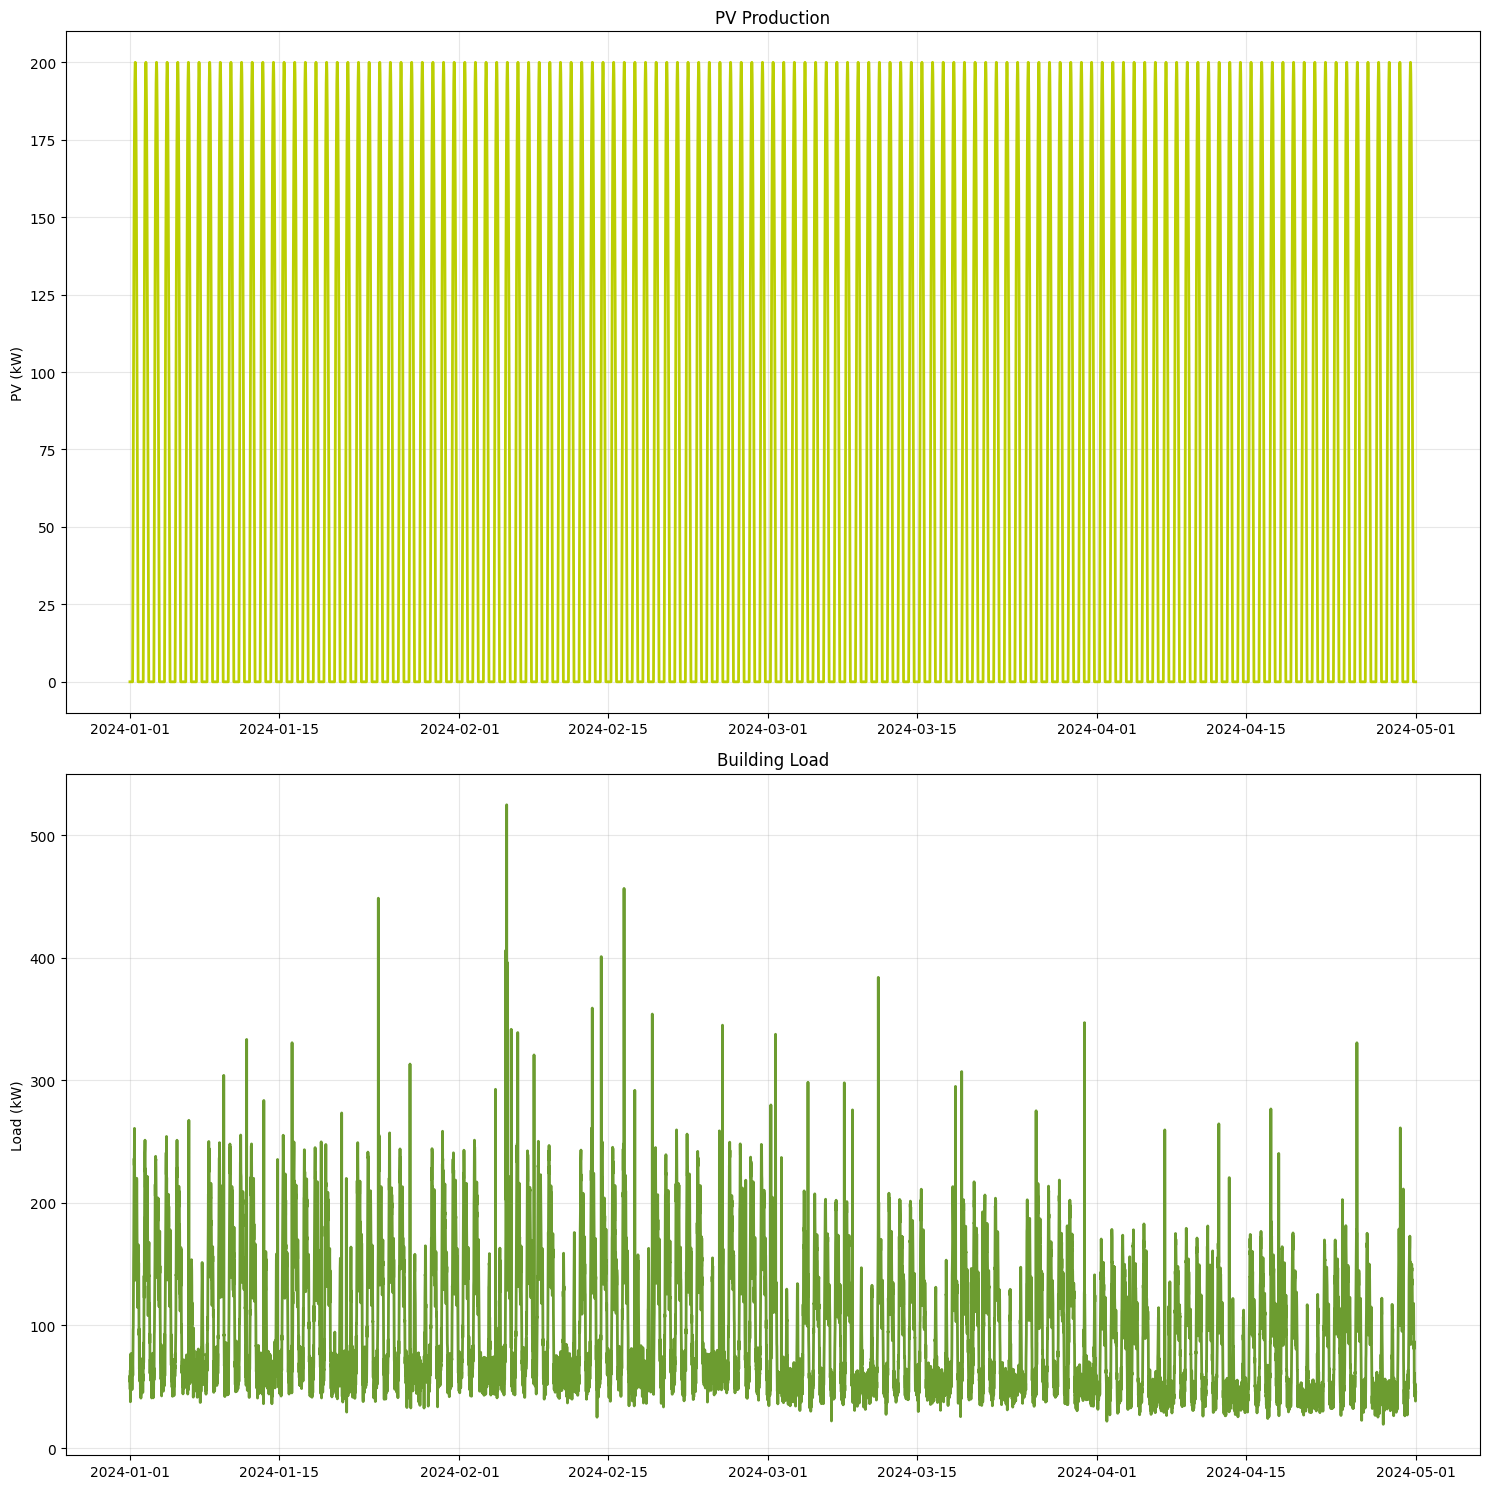

In [4]:
import matplotlib.pyplot as plt

# ==================== VISUALIZATION ====================
fig, axes = plt.subplots(2, 1, figsize=(15, 15))

# PV Production
axes[0].plot(df_inputs.index, df_inputs['pv_production'], color='#BCCF02', linewidth=2)
axes[0].set_ylabel('PV (kW)')
axes[0].set_title('PV Production')
axes[0].grid(True, alpha=0.3)

# laod or price
axes[1].plot(df_inputs.index, df_inputs['load_building'], color='#6C9C30', linewidth=2)
axes[1].set_ylabel('Load (kW)')
axes[1].set_title('Building Load')
axes[1].grid(True, alpha=0.3)

# # EV Soc min und max
# axes[2].plot(ev_data.index, ev_data['soc_max'], color='green', linewidth=2, label='Max SoC')
# axes[2].plot(ev_data.index, ev_data['soc_min'], color='red', linewidth=2, label='Min SoC')
# axes[2].set_ylabel('SoC (0-1)')
# axes[2].set_title('State of Charge boundaries')
# axes[2].grid(True, alpha=0.3)

# # EV Capacity
# axes[3].plot(ev_data.index, ev_data['energy_capacity'], color='#a7b805', linewidth=2)
# axes[3].set_ylabel('Capacity (kWh)')
# axes[3].set_title('EV Fleet Capacity')
# axes[3].grid(True, alpha=0.3)

# # EV Power
# axes[4].plot(ev_data.index, ev_data['power_max'], color='green', linewidth=2, label='Max Charge')
# axes[4].plot(ev_data.index, ev_data['power_min'], color='red', linewidth=2, label='Min Charge')
# axes[4].set_ylabel('Power (kW)')
# axes[4].set_xlabel('Time')
# axes[4].set_title('EV Power Limits')
# axes[4].legend()
# axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
from hems_resopt.components.grid import GridPeakShave
# Set up to test 
model = EnergyModel(
    name='Logistik',
    num_steps=len(df_inputs.index),
    slot_length='15min',
    solver='scip'
)


Building = Load(
    name='Logistik_Zentrum',
    load_curve=df_inputs['load_building'],
    lost_load_allowed=True,
    value_of_lost_load=1000.0
)

battery = Battery(
    name='Shaver',
    power_nominal=100,
    energy_capacity=2000
)


DA = AuctionMarket(
    price_curve=df_inputs['da_price_curve'],
    market_time_unit='15min'
)

grid = GridPeakShave(
    assets=[Building, battery],
    markets=[DA],
    # power_max=1000,
    # power_min=-1000,   # physical power line limits
    peak_power_price=100000000,
    time_horizon_peak='week'
    )

model.add_component(Building)
model.add_component(battery)
model.add_component(grid)
model.add_component(DA)
model.build_and_run(silent=False)

SCIP version 10.0.2 [precision: 8 byte] [memory: block] [mode: optimized] [LP solver: SoPlex 8.0.2] [GitHash: b8eaf989f9]
Copyright (c) 2002-2026 Zuse Institute Berlin (ZIB)

External libraries: 
  SoPlex 8.0.2         Linear programming solver developed at Zuse Institute Berlin (soplex.zib.de) [GitHash: cfadddc4]
  CppAD 20180000.0     Algorithmic Differentiation of C++ algorithms developed by B. Bell (github.com/coin-or/CppAD)
  ZLIB 1.3.2           General purpose compression library by J. Gailly and M. Adler (zlib.net)
  MPFR 4.2.2           GNU Multiple Precision Floating-Point Reliable Library (mpfr.org)
  Boost 1.88.0         Boost C++ Libraries (boost.org)
  TinyCThread 1.2      small portable implementation of the C11 threads API (tinycthread.github.io)
  GMP 6.3.0            GNU Multiple Precision Arithmetic Library developed by T. Granlund (gmplib.org)
  ZIMPL 3.7.1          Zuse Institute Mathematical Programming Language developed by T. Koch (zimpl.zib.de)
  AMPL/MP 4.0.4 

In [12]:
df_results = model.results.timeseries_to_pandas()


# what is the actual load at the meter where peak shaving is conducted? 


In [13]:
df_results['load_meter'] = df_results['Logistik_Zentrum__var_power']+ df_results['Shaver__var_power']

print('load_meter' in df_results.columns)
print(df_results['load_meter'].describe())

True
count    11612.000000
mean      -101.665683
std        104.501976
min       -453.977942
25%       -166.249566
50%       -137.804932
75%          1.653847
max         80.658761
Name: load_meter, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_results(
    df: pd.DataFrame,
    columns: list[str],
    title: str = "Model Results",
    ylabel: str = "Power [kW]",
    figsize: tuple = (14, 5),
    timestamp_col: str = "timestamp",
) -> None:
    """Plots selected columns from a results DataFrame as time series lines.

    Args:
        df: Results DataFrame, typically from model.results.timeseries_to_pandas().
        columns: List of column names to plot.
        title: Title of the plot.
        ylabel: Label for the y-axis.
        figsize: Figure size as (width, height).
        timestamp_col: Name of the timestamp column to use as x-axis.
    """
    fig, ax = plt.subplots(figsize=figsize)

    # use timestamp as x-axis if available, otherwise fall back to integer index
    x = df[timestamp_col] if timestamp_col in df.columns else df.index

    for col in columns:
        if col not in df.columns:
            print(f"Warning: column '{col}' not found in DataFrame — skipping.")
            continue
        ax.plot(x, df[col], label=col, linewidth=1.0)

    # format x-axis as dates if timestamps are available
    if timestamp_col in df.columns:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
        fig.autofmt_xdate()

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


In [9]:
print(df_results.columns.tolist())

['Logistik_Zentrum__var_power', 'Logistik_Zentrum__var_power_reserve_up', 'Logistik_Zentrum__var_power_reserve_down', 'Logistik_Zentrum__var_lost_load', 'Shaver__var_power', 'Shaver__var_power_reserve_up', 'Shaver__var_power_reserve_down', 'Shaver__var_soc_slot_start', 'Shaver__var_soc_slot_end', 'Shaver__var_min_energy_violation', 'Shaver__var_max_energy_violation', 'Shaver__var_power_charge', 'Shaver__var_power_discharge', 'Shaver__var_is_charging', 'Shaver__var_is_discharging', 'Shaver__var_power_max_violation', 'Shaver__var_power_min_violation', 'Shaver__var_energy_reserve_up_slot_start', 'Shaver__var_energy_reserve_down_slot_start', 'Shaver__var_energy_reserve_up_slot_end', 'Shaver__var_energy_reserve_down_slot_end', 'Shaver__var_soc_min_soft_violation', 'Shaver__var_soc_max_soft_violation', 'grid_peak_shave__var_peak_power', 'auction_market__var_power', 'timestamp', 'load_meter']


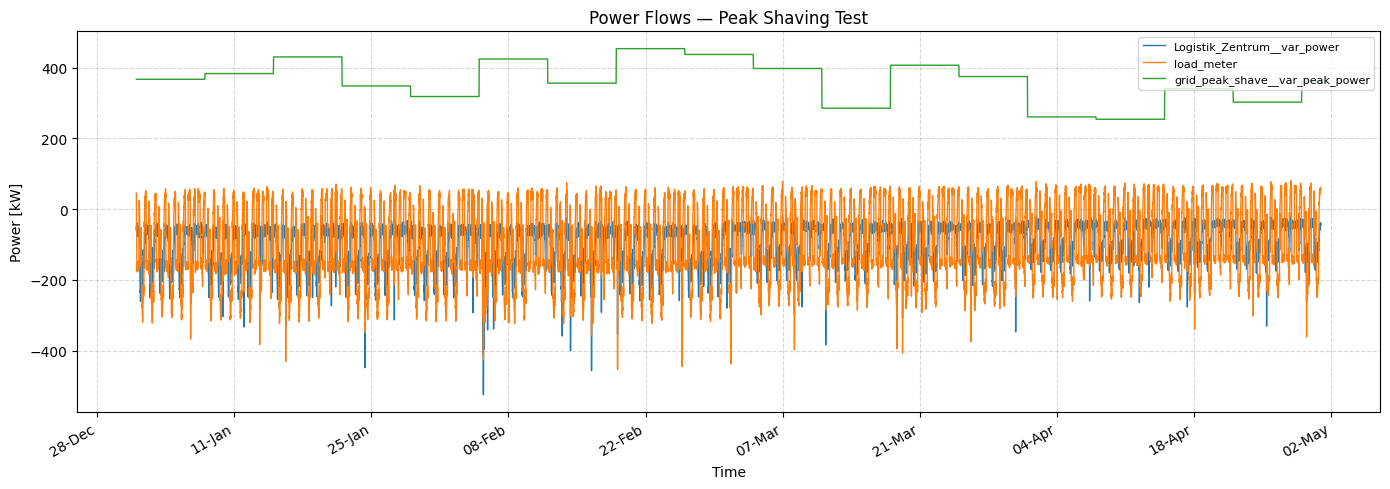

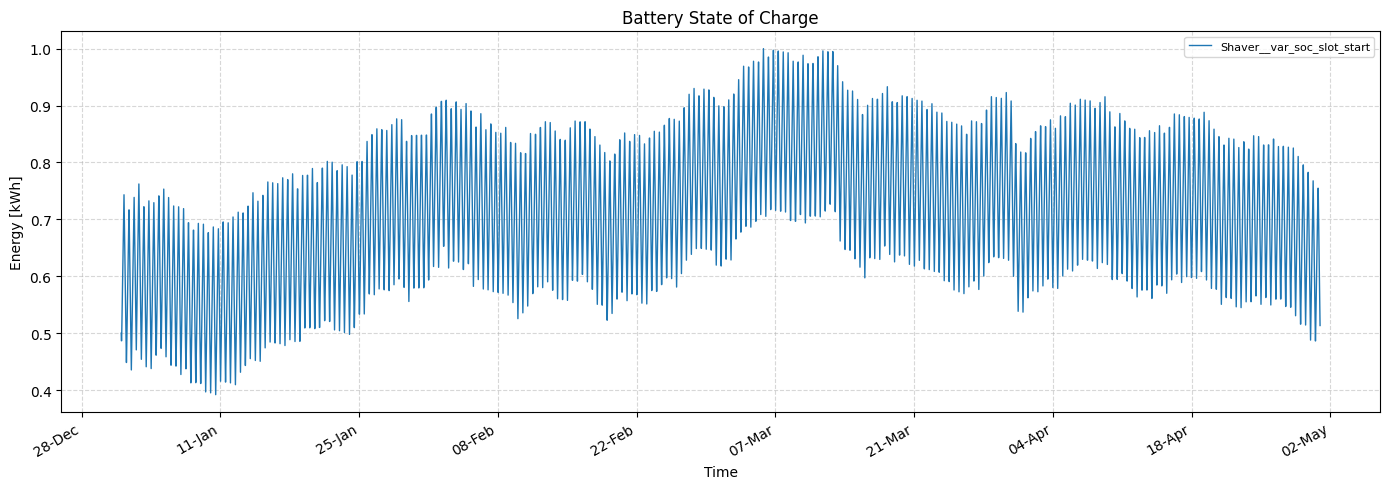

In [ ]:


# plot power flows
plot_results(
    df=df_results,
    columns=[
        "Logistik_Zentrum__var_power",
        "load_meter",
        #"Shaver__var_power",
        "grid_peak_shave__var_peak_power",
    ],
    title="Power Flows — Peak Shaving Test",
    ylabel="Power [kW]",
)

# plot battery SoC separately
plot_results(
    df=df_results,
    columns=["Shaver__var_soc_slot_start"],
    title="Battery State of Charge",
    ylabel="Energy [kWh]",
)
